In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from datetime import datetime
from pyspark.sql import functions as F
from pyspark.errors import PySparkException

In [26]:
try:
    # DESCRIBE DETAIL helps to monitor dim and facts freshnesses
    brze_dim_carburant = spark.sql("DESCRIBE DETAIL fuel_price_dev.bronze.brze_dim_carburant ")
    brze_dim_geo       = spark.sql("DESCRIBE DETAIL fuel_price_dev.bronze.brze_dim_geo")
    brze_dim_station   = spark.sql("DESCRIBE DETAIL fuel_price_dev.bronze.brze_dim_station")
    brze_fait_prix   = spark.sql("  DESCRIBE DETAIL fuel_price_dev.bronze.brze_fait_prix")
    brze_fait_rupture   = spark.sql("DESCRIBE DETAIL fuel_price_dev.bronze.brze_fait_rupture")

    # lastModified time gives us a rudimentary view into xxxx_freshness
    dim_carburant_update_times = brze_dim_carburant.select(
        "id",
        "name",
        "lastModified"
        )\
        .withColumn("measureAt", F.lit(datetime.now().isoformat()))
    
    brze_dim_geo_update_times = brze_dim_geo.select(
        "id",
        "name",
        "lastModified"
        )\
        .withColumn("measureAt", F.lit(datetime.now().isoformat()))

    brze_dim_station_update_times = brze_dim_station.select(
        "id",
        "name",
        "lastModified"
        )\
        .withColumn("measureAt", F.lit(datetime.now().isoformat()))
   

    brze_fait_prix_update_times = brze_fait_prix.select(
        "id",
        "name",
        "lastModified"
        )\
        .withColumn("measureAt", F.lit(datetime.now().isoformat()))

    brze_fait_rupture_update_times = brze_fait_rupture.select(
        "id",
        "name",
        "lastModified"
        )\
        .withColumn("measureAt", F.lit(datetime.now().isoformat()))
    
    dim_carburant_update_times.write.mode("append").saveAsTable("fuel_price_dev.bronze.bronze_update_times")
    brze_dim_geo_update_times.write.mode("append").saveAsTable("fuel_price_dev.bronze.bronze_update_times")
    brze_dim_station_update_times.write.mode("append").saveAsTable("fuel_price_dev.bronze.bronze_update_times")
    brze_fait_prix_update_times.write.mode("append").saveAsTable("fuel_price_dev.bronze.bronze_update_times")
    brze_fait_rupture_update_times.write.mode("append").saveAsTable("fuel_price_dev.bronze.bronze_update_times")

    # From here, we have appended to a freshness-tracking table called bronze_update_times
except PySparkException as e:
    if e.getErrorClass() == "TABLE_OR_VIEW_NOT_FOUND":
        print(f"Source table not found: {e.getMessageParameters()['relationName']} ")
    else:
        raise 


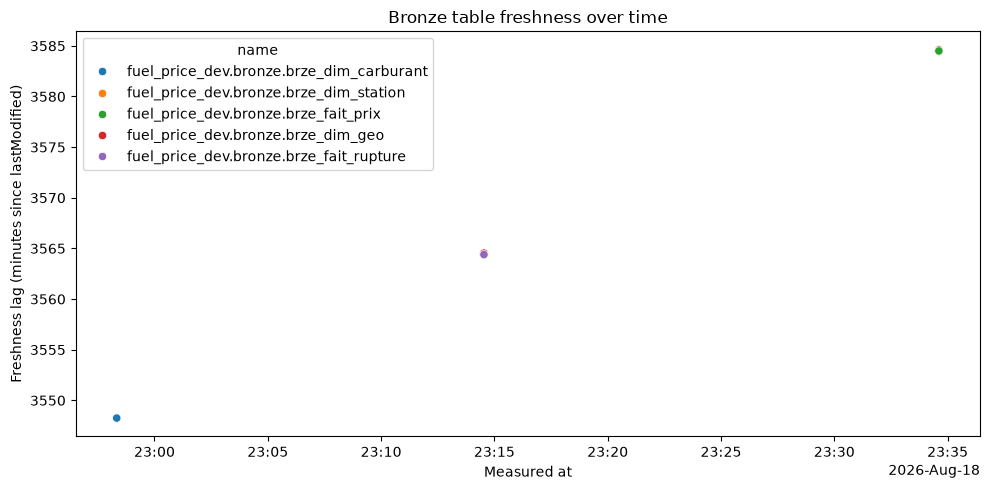

In [28]:
time_series = spark.sql("""
            SELECT DISTINCT
            name,
            measureAt,
            lastModified
            FROM fuel_price_dev.bronze.bronze_update_times
            ORDER BY measureAt ASC
            LIMIT 400
    """).toPandas()
time_series.lastModified = pd.to_datetime(time_series.lastModified)
time_series.measureAt = pd.to_datetime(time_series.measureAt)

# freshness lag: how stale each table was at the moment it was measured
time_series["lag_minutes"] = (time_series.measureAt - time_series.lastModified).dt.total_seconds() / 60

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=time_series, x="measureAt", y="lag_minutes", hue="name", marker="o", ax=ax)

ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set_ylabel("Freshness lag (minutes since lastModified)")
ax.set_xlabel("Measured at")
ax.set_title("Bronze table freshness over time")
plt.tight_layout()